In [3]:
# Import libraries
import scanpy as sc
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score, classification_report
import celltypist
import scipy.sparse as sp

/usr/local/lib/python3.13/dist-packages/celltypist/classifier.py:11: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  from scanpy import __version__ as scv


In [ ]:
# Load AIDA dataset in backed mode to avoid loading all data into memory
adata = sc.read_h5ad('AIDA.h5ad', backed='r')
print(adata)

AnnData object with n_obs × n_vars = 1265624 × 35477 backed at 'AIDA.h5ad'
    obs: 'reference_genome', 'gene_annotation_version', 'alignment_software', 'intronic_reads_counted', 'library_id', 'assay_ontology_term_id', 'sequenced_fragment', 'cell_number_loaded', 'institute', 'is_primary_data', 'cell_type_ontology_term_id', 'author_cell_type', 'sample_id', 'sample_preservation_method', 'tissue_ontology_term_id', 'development_stage_ontology_term_id', 'sample_collection_method', 'donor_BMI_at_collection', 'tissue_type', 'suspension_derivation_process', 'suspension_enriched_cell_types', 'cell_viability_percentage', 'suspension_uuid', 'suspension_type', 'donor_id', 'self_reported_ethnicity_ontology_term_id', 'donor_living_at_sample_collection', 'disease_ontology_term_id', 'sex_ontology_term_id', 'nCount_RNA', 'nFeature_RNA', 'pMito', 'NODG', 'nUMI', 'Country', 'Annotation_Level1', 'Annotation_Level2', 'Annotation_Level3', 'Annotation_Level4', 'Smoking Status', 'cell_type', 'assay', 'disease

In [ ]:
# Fix query donors (seed=42)
sg_chinese_donors = adata.obs[
    adata.obs['self_reported_ethnicity'] == 'Singaporean Chinese'
]['donor_id'].unique()

np.random.seed(42)
query_donors = np.random.choice(sg_chinese_donors, size=20, replace=False)
ref_candidate_donors = sg_chinese_donors[~np.isin(sg_chinese_donors, query_donors)]

# All other ethnic groups as reference pool
all_other_donors = adata.obs[
    adata.obs['self_reported_ethnicity'].isin([
        'Japanese', 'Korean', 'Thai', 'Indian',
        'Singaporean Malay', 'Singaporean Indian'
    ])
]['donor_id'].unique()

print(f"Query donors: {len(query_donors)}")
print(f"SG_Chinese reference candidates: {len(ref_candidate_donors)}")
print(f"Other ethnic groups: {len(all_other_donors)}")

Query donors: 20
SG_Chinese reference candidates: 65
Other ethnic groups: 534


In [ ]:
def run_celltypist(adata, query_donors, other_donors, ref_candidate_donors,
                   sg_chinese_proportion, n_ref_total=60):

    n_chinese = int(n_ref_total * sg_chinese_proportion)
    n_others = n_ref_total - n_chinese

    if n_chinese > 0:
        chinese_ref = np.random.choice(ref_candidate_donors, size=n_chinese, replace=False)
    else:
        chinese_ref = []

    other_ref = np.random.choice(other_donors, size=n_others, replace=False)
    all_ref_donors = list(chinese_ref) + list(other_ref)

    print(f"  Building reference ({len(all_ref_donors)} donors)...")
    ref_cells = adata.obs['donor_id'].isin(all_ref_donors)
    ref_adata = adata[ref_cells].to_memory()
    print(f"  Reference loaded: {ref_adata.n_obs} cells")

    print(f"  Selecting highly variable genes...")
    sc.pp.highly_variable_genes(ref_adata, n_top_genes=2000)
    ref_adata = ref_adata[:, ref_adata.var['highly_variable']]

    print(f"  Training CellTypist model...")
    model = celltypist.train(ref_adata, labels='cell_type', n_jobs=-1, with_mean=False, check_expression=False)
    print(f"  Model trained")

    print(f"  Processing query...")
    query = adata[adata.obs['donor_id'].isin(query_donors)].to_memory()
    query = query[:, ref_adata.var_names]
    query = query.copy()
    if sp.issparse(query.X):
        query.X = query.X.toarray()

    print(f"  Predicting...")
    predictions = celltypist.annotate(query, model=model)

    true_labels = query.obs['cell_type']
    pred_labels = predictions.predicted_labels['predicted_labels']
    f1 = f1_score(true_labels, pred_labels, average='macro')
    print(f"  F1: {f1:.4f}")

    return f1, predictions, query

print("Function ready")

Function ready


## ⚠️ WARNING: Do NOT run this cell
This cell runs 36 rounds × 11 proportions of CellTypist training (~6 hours).
Results are already saved to `results_full_curve.csv` and `all_reports.json`.
Only run if you need to reproduce the experiment from scratch.


In [ ]:
import json
import pandas as pd
from sklearn.metrics import classification_report

proportions = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
n_repeats = 10
all_results = []
all_reports = []

SAVE_DIR = './output'

for i in range(n_repeats):
    print(f"\n=== Round {i+1} ===")
    for prop in proportions:
        print(f"  Running {prop*100:.0f}% SG_Chinese...")
        f1, predictions, query = run_celltypist(
            adata, query_donors, all_other_donors,
            ref_candidate_donors, sg_chinese_proportion=prop,
            n_ref_total=60
        )

        true_labels = query.obs['cell_type']
        pred_labels = predictions.predicted_labels['predicted_labels']
        report = classification_report(true_labels, pred_labels, output_dict=True)

        all_results.append({'proportion': prop, 'repeat': i, 'f1': f1})
        all_reports.append({'proportion': prop, 'repeat': i, 'report': report})
        print(f"  F1: {f1:.4f}")


        pd.DataFrame(all_results).to_csv(f'{SAVE_DIR}/results_full_curve.csv', index=False)
        with open(f'{SAVE_DIR}/all_reports.json', 'w') as f:
            json.dump(all_reports, f)

df_results = pd.DataFrame(all_results)
print("\nMean F1 by proportion:")
print(df_results.groupby('proportion')['f1'].mean())

In [ ]:
import json
import pandas as pd

SAVE_DIR = './output'

# Load existing results
with open(f'{SAVE_DIR}/all_reports.json', 'r') as f:
    all_reports = json.load(f)

all_results = pd.read_csv(f'{SAVE_DIR}/results_full_curve.csv').to_dict('records')

# Determine starting round
next_round = pd.read_csv(f'{SAVE_DIR}/results_full_curve.csv')['repeat'].max() + 1
print(f"Completed {next_round} rounds so far, resuming from round {next_round + 1}")

# Continue running
proportions = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
n_extra_rounds = 0  # change this to run more rounds

for i in range(next_round, next_round + n_extra_rounds):
    print(f"\n=== Round {i+1} ===")
    for prop in proportions:
        print(f"  Running {prop*100:.0f}% SG_Chinese...")
        f1, predictions, query = run_celltypist(
            adata, query_donors, all_other_donors,
            ref_candidate_donors, sg_chinese_proportion=prop,
            n_ref_total=60
        )

        true_labels = query.obs['cell_type']
        pred_labels = predictions.predicted_labels['predicted_labels']
        report = classification_report(true_labels, pred_labels, output_dict=True)

        all_results.append({'proportion': prop, 'repeat': i, 'f1': f1})
        all_reports.append({'proportion': prop, 'repeat': i, 'report': report})
        print(f"  F1: {f1:.4f}")

        pd.DataFrame(all_results).to_csv(f'{SAVE_DIR}/results_full_curve.csv', index=False)
        with open(f'{SAVE_DIR}/all_reports.json', 'w') as f:
            json.dump(all_reports, f)

print("Done")

Completed 36 rounds so far, resuming from round 37
Done


In [ ]:
import pandas as pd
df_results = pd.read_csv('./output/results_full_curve.csv')
print(df_results.groupby('proportion')['f1'].mean())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
proportion
0.0    0.811221
0.1    0.813153
0.2    0.817532
0.3    0.818152
0.4    0.821324
0.5    0.816253
0.6    0.818628
0.7    0.813780
0.8    0.814608
0.9    0.820866
1.0    0.822273
Name: f1, dtype: float64


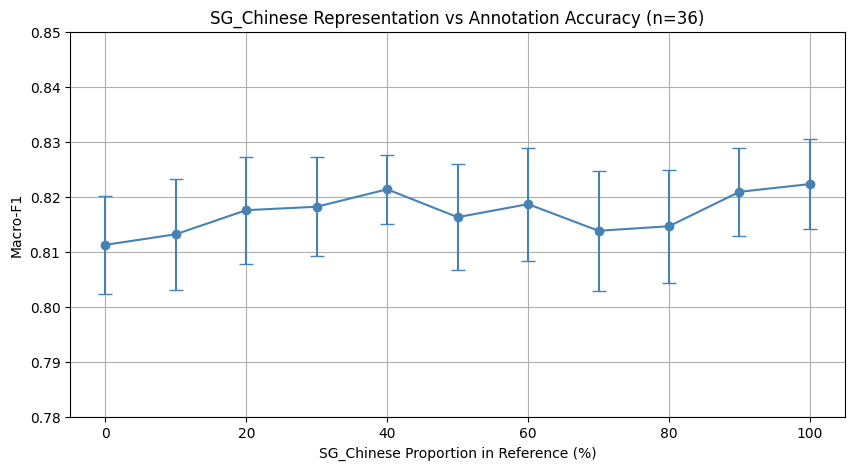

In [ ]:
import matplotlib.pyplot as plt

df_results = pd.read_csv('./output/results_full_curve.csv')

means = df_results.groupby('proportion')['f1'].mean()
stds = df_results.groupby('proportion')['f1'].std()
n = df_results['repeat'].max() + 1

plt.figure(figsize=(10, 5))
plt.errorbar([p*100 for p in means.index], means.values,
             yerr=stds.values, fmt='o-', capsize=5, color='steelblue')
plt.xlabel('SG_Chinese Proportion in Reference (%)')
plt.ylabel('Macro-F1')
plt.title(f'SG_Chinese Representation vs Annotation Accuracy (n={n})')
plt.ylim(0.78, 0.85)
plt.grid(True)
plt.savefig('./output/dose_response_final.png')
plt.show()

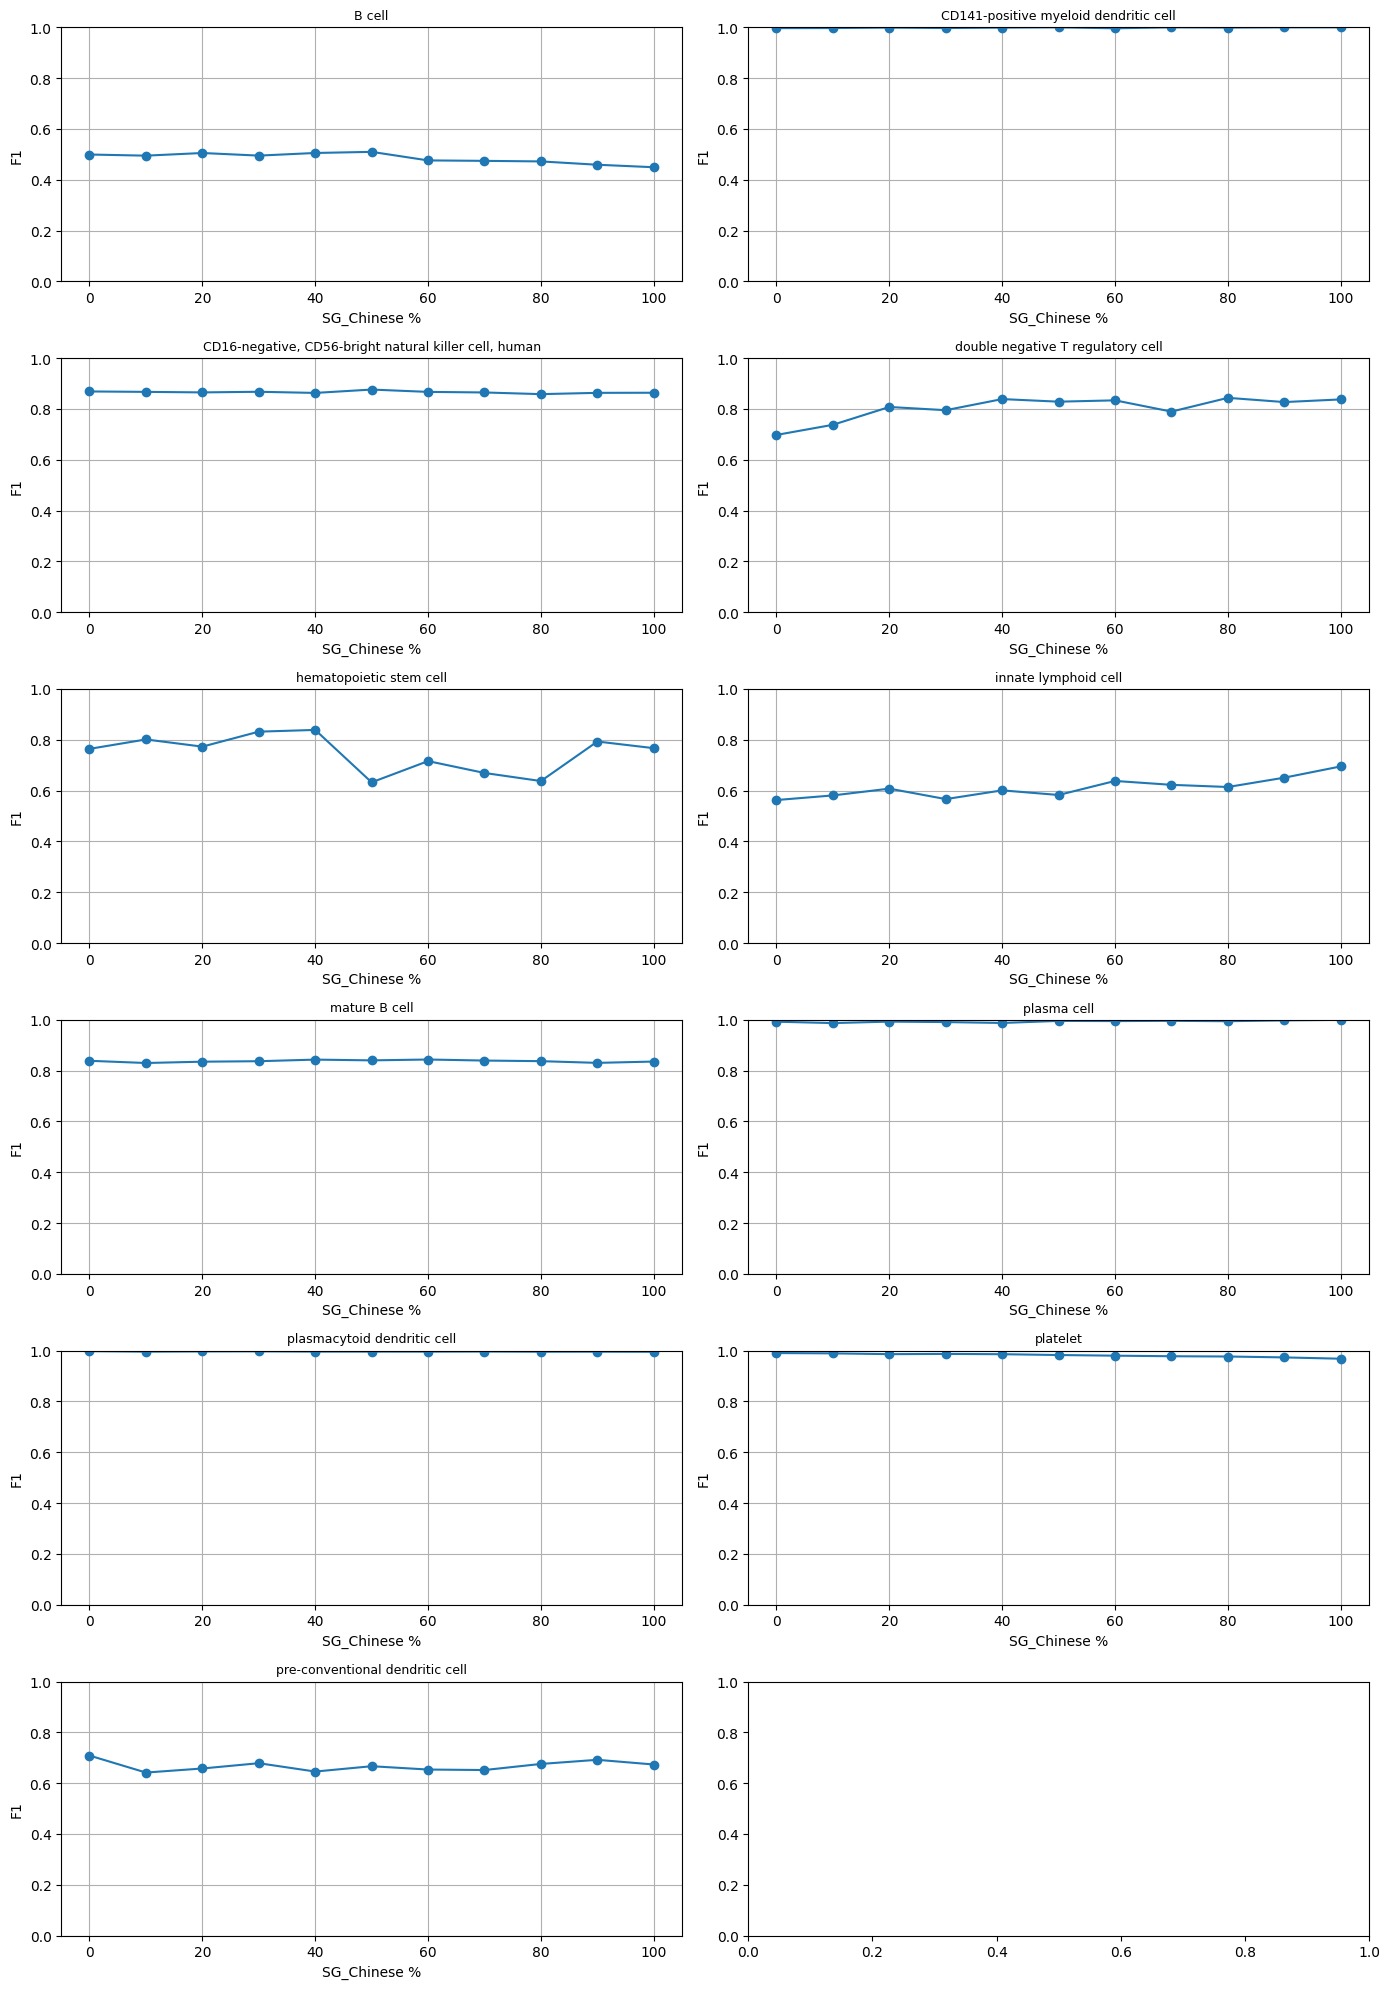

In [ ]:
import json
import pandas as pd
import matplotlib.pyplot as plt

# Load all_reports
with open('./output/all_reports.json', 'r') as f:
    all_reports = json.load(f)

# Compile per-cell-type F1 scores
cell_type_results = []

for entry in all_reports:
    prop = entry['proportion']
    repeat = entry['repeat']
    report = entry['report']

    for cell_type, metrics in report.items():
        if cell_type in ['accuracy', 'macro avg', 'weighted avg']:
            continue
        if isinstance(metrics, dict):
            cell_type_results.append({
                'proportion': prop,
                'cell_type': cell_type,
                'f1': metrics['f1-score'],
                'support': metrics['support']
            })

df_cell = pd.DataFrame(cell_type_results)

# Identify rare cell types (mean support < 200)
rare_cells = df_cell.groupby('cell_type')['support'].mean()
rare_cells = rare_cells[rare_cells < 200].index

# Mean F1 by proportion for each rare cell type
mean_by_cell = df_cell[df_cell['cell_type'].isin(rare_cells)].groupby(
    ['cell_type', 'proportion'])['f1'].mean().unstack()

# Plot
fig, axes = plt.subplots(len(rare_cells) // 2 + 1, 2, figsize=(14, 20))
axes = axes.flatten()

for idx, cell_type in enumerate(rare_cells):
    if cell_type in mean_by_cell.index:
        axes[idx].plot([p*100 for p in mean_by_cell.columns],
                       mean_by_cell.loc[cell_type].values, 'o-')
        axes[idx].set_title(cell_type, fontsize=9)
        axes[idx].set_xlabel('SG_Chinese %')
        axes[idx].set_ylabel('F1')
        axes[idx].set_ylim(0, 1)
        axes[idx].grid(True)

plt.tight_layout()
plt.savefig('./output/rare_celltypes_curve.png')
plt.show()

In [6]:
import json
import pandas as pd

# Load all_reports
with open('./output/all_reports.json', 'r') as f:
    all_reports = json.load(f)

# Compile per-cell-type F1 scores
cell_type_results = []

for entry in all_reports:
    prop = entry['proportion']
    report = entry['report']

    for cell_type, metrics in report.items():
        if cell_type in ['accuracy', 'macro avg', 'weighted avg']:
            continue
        if isinstance(metrics, dict):
            cell_type_results.append({
                'proportion': prop,
                'cell_type': cell_type,
                'f1': metrics['f1-score'],
                'support': metrics['support']
            })

df_cell = pd.DataFrame(cell_type_results)
mean_by_cell = df_cell.groupby(['cell_type', 'proportion'])['f1'].mean().unstack()

print("Mean F1 by cell type:")
print(mean_by_cell.round(3))

Mean F1 by cell type:
proportion                                            0.0    0.1    0.2  \
cell_type                                                                 
B cell                                              0.499  0.495  0.505   
CD14-low, CD16-positive monocyte                    0.963  0.963  0.962   
CD14-positive monocyte                              0.972  0.972  0.973   
CD141-positive myeloid dendritic cell               0.997  0.997  0.999   
CD16-negative, CD56-bright natural killer cell,...  0.869  0.867  0.865   
CD16-positive, CD56-dim natural killer cell, human  0.975  0.976  0.976   
CD1c-positive myeloid dendritic cell                0.904  0.897  0.902   
CD4-positive, alpha-beta T cell                     0.297  0.306  0.312   
CD4-positive, alpha-beta cytotoxic T cell           0.815  0.820  0.822   
CD8-positive, alpha-beta T cell                     0.684  0.687  0.681   
CD8-positive, alpha-beta cytotoxic T cell           0.820  0.824  0.821   
CD8

In [7]:
# F1 difference between 100% and 0% SG_Chinese reference
diff = mean_by_cell[1.0] - mean_by_cell[0.0]
diff = diff.sort_values()

print("F1 difference (100% - 0% SG_Chinese):")
print(diff.round(3))

F1 difference (100% - 0% SG_Chinese):
cell_type
B cell                                                  -0.050
pre-conventional dendritic cell                         -0.035
T cell                                                  -0.027
platelet                                                -0.022
myeloid cell                                            -0.007
CD16-negative, CD56-bright natural killer cell, human   -0.005
CD14-low, CD16-positive monocyte                        -0.004
mature B cell                                           -0.003
plasmacytoid dendritic cell                             -0.003
gamma-delta T cell                                      -0.002
memory B cell                                           -0.001
CD14-positive monocyte                                   0.000
CD16-positive, CD56-dim natural killer cell, human       0.001
naive B cell                                             0.001
CD4-positive, alpha-beta cytotoxic T cell                0.002
hematop

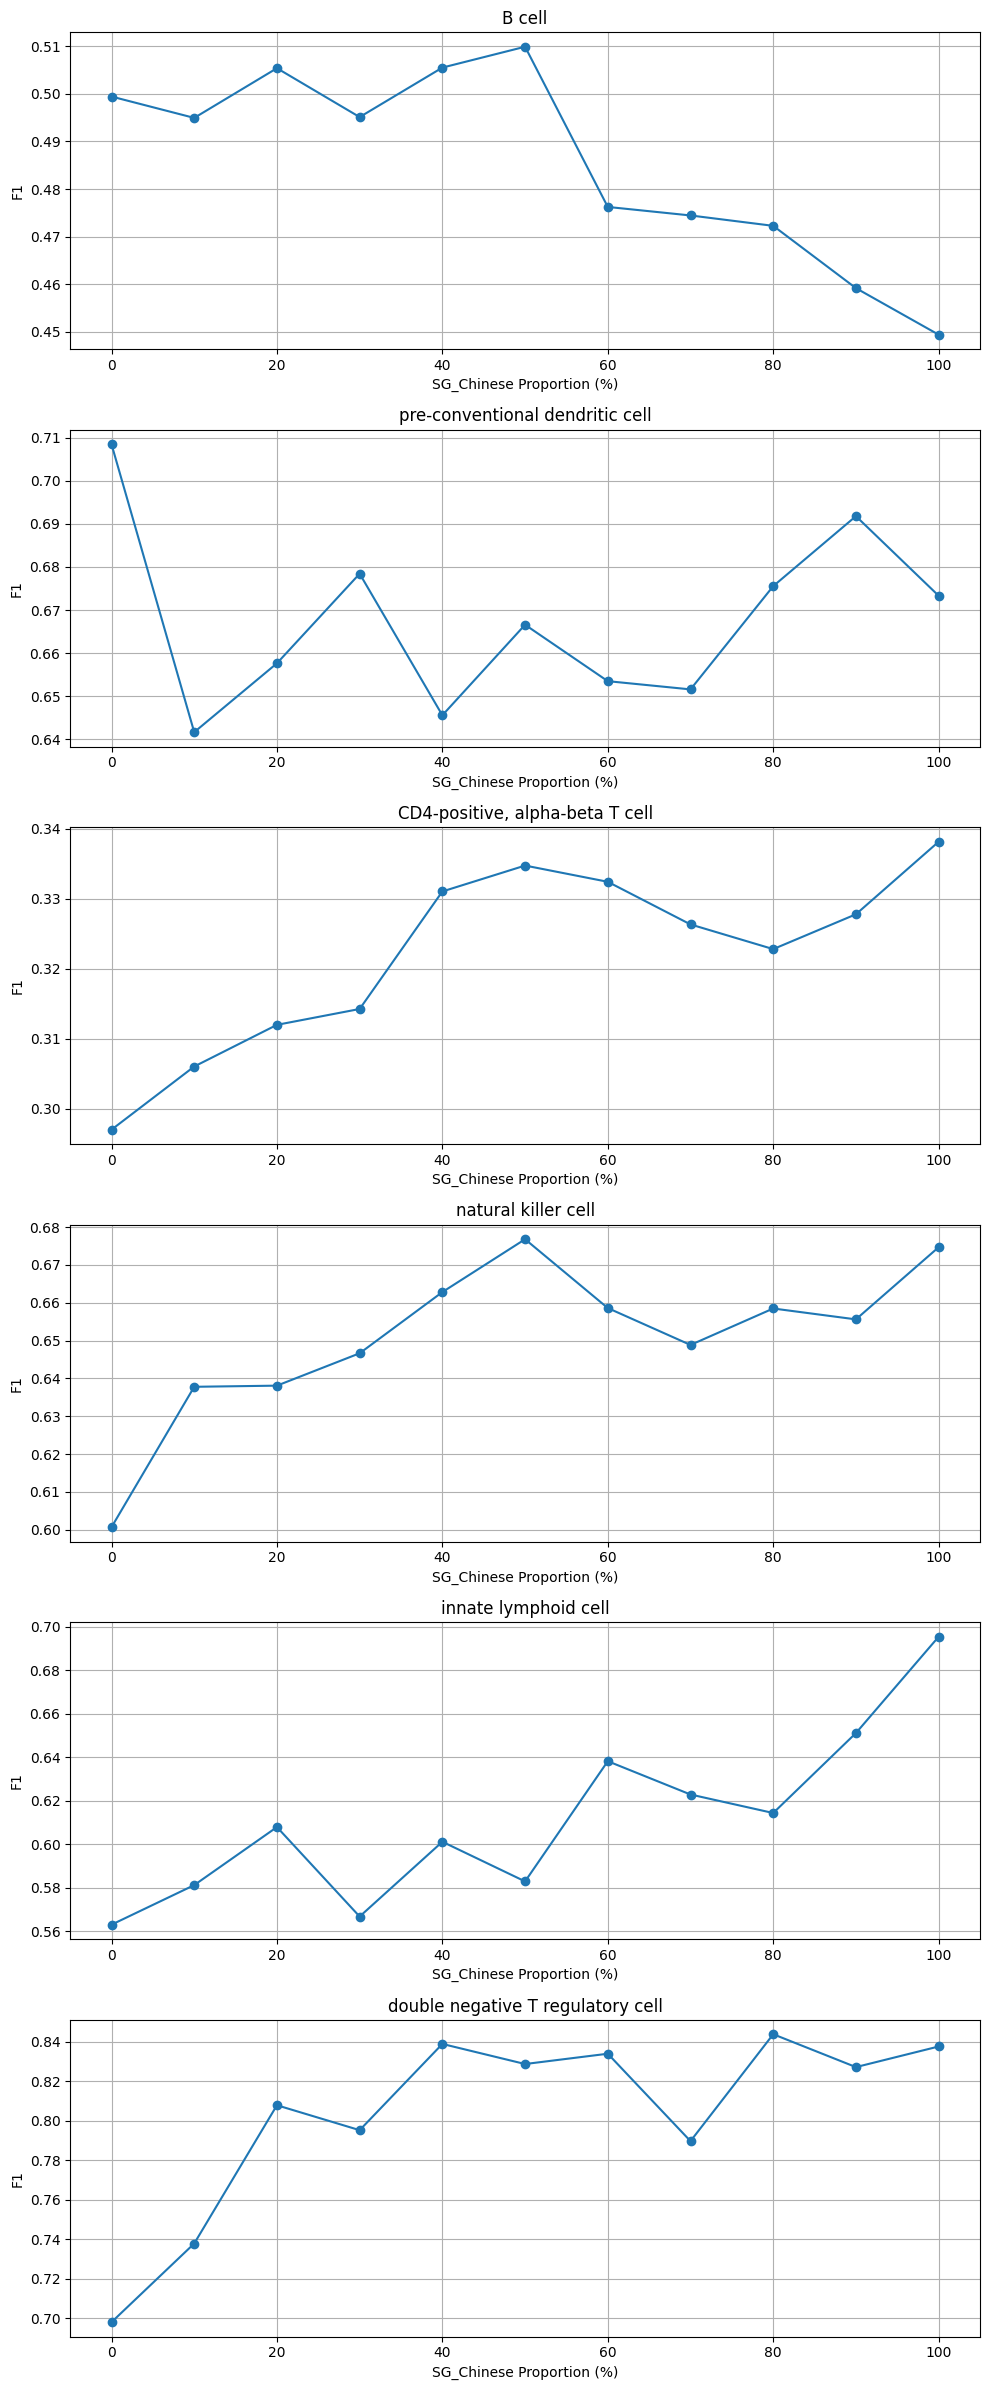

In [ ]:
import matplotlib.pyplot as plt

# Select cell types with largest F1 difference (absolute value > 0.03)
important_cells = diff[abs(diff) > 0.03].index.tolist()

fig, axes = plt.subplots(len(important_cells), 1, figsize=(10, 4*len(important_cells)))

for idx, cell_type in enumerate(important_cells):
    axes[idx].plot([p*100 for p in mean_by_cell.columns],
                   mean_by_cell.loc[cell_type].values, 'o-')
    axes[idx].set_title(cell_type)
    axes[idx].set_xlabel('SG_Chinese Proportion (%)')
    axes[idx].set_ylabel('F1')
    axes[idx].grid(True)

plt.tight_layout()
plt.savefig('./output/important_celltypes_curve.png')
plt.show()

In [13]:
# Select cell types with largest F1 difference (absolute value > 0.03)
important_cells = diff[abs(diff) > 0.03].index.tolist()

# Compile full data for these cell types
df_important = df_cell[df_cell['cell_type'].isin(important_cells)].copy()

# Save to output folder
df_important.to_csv('./output/important_celltypes.csv', index=False)
print("Saved")
print(f"Cell types included: {important_cells}")
print(df_important.groupby(['cell_type', 'proportion'])['f1'].mean().round(3))


Saved
Cell types included: ['B cell', 'pre-conventional dendritic cell', 'CD4-positive, alpha-beta T cell', 'natural killer cell', 'innate lymphoid cell', 'double negative T regulatory cell']
cell_type                        proportion
B cell                           0.0           0.499
                                 0.1           0.495
                                 0.2           0.505
                                 0.3           0.495
                                 0.4           0.506
                                               ...  
pre-conventional dendritic cell  0.6           0.653
                                 0.7           0.652
                                 0.8           0.676
                                 0.9           0.692
                                 1.0           0.673
Name: f1, Length: 66, dtype: float64


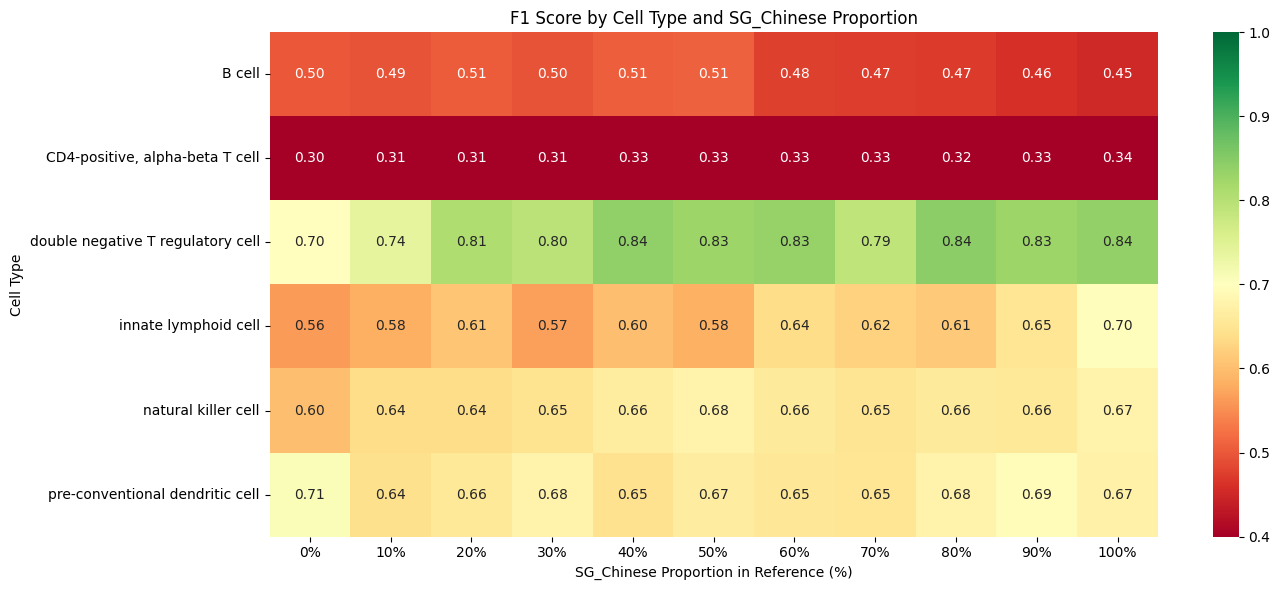

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Reshape to heatmap format
pivot = df_important.groupby(['cell_type', 'proportion'])['f1'].mean().unstack()

plt.figure(figsize=(14, 6))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn',
            xticklabels=[f'{int(p*100)}%' for p in pivot.columns],
            vmin=0.4, vmax=1.0)
plt.xlabel('SG_Chinese Proportion in Reference (%)')
plt.ylabel('Cell Type')
plt.title('F1 Score by Cell Type and SG_Chinese Proportion')
plt.tight_layout()
plt.savefig('./output/heatmap_important_celltypes.png')
plt.show()

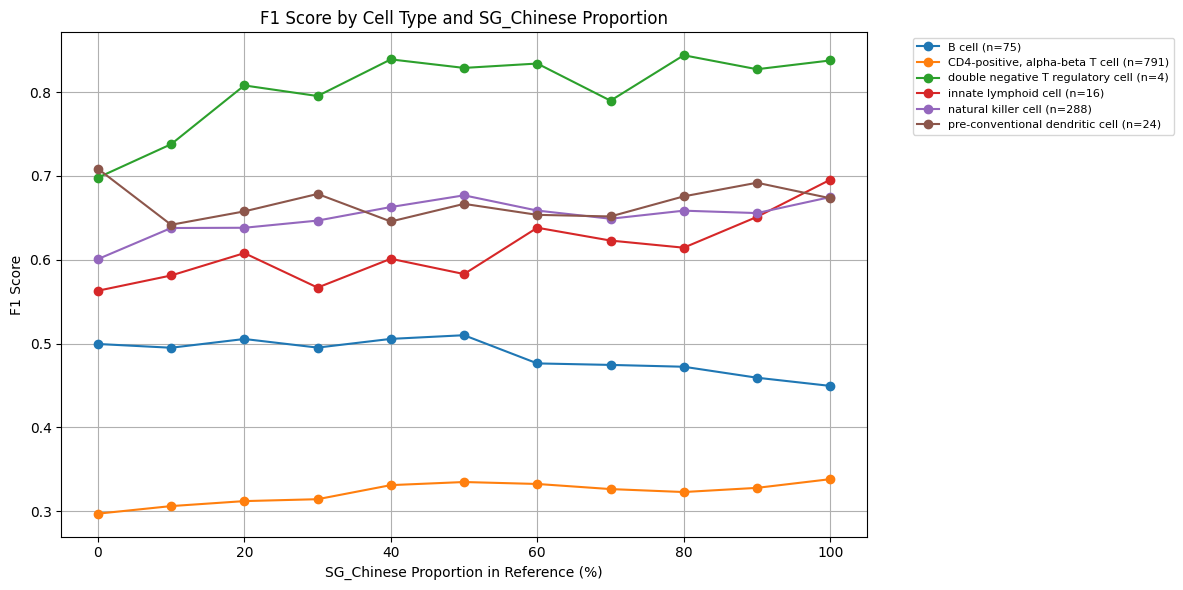

In [ ]:
import matplotlib.pyplot as plt

# Calculate mean support per cell type
support_by_cell = df_important.groupby('cell_type')['support'].mean().round(0).astype(int)

pivot = df_important.groupby(['cell_type', 'proportion'])['f1'].mean().unstack()

plt.figure(figsize=(12, 6))

for cell_type in pivot.index:
    support = support_by_cell[cell_type]
    plt.plot([p*100 for p in pivot.columns],
             pivot.loc[cell_type].values,
             'o-', label=f'{cell_type} (n={support})', linewidth=1.5)

plt.xlabel('SG_Chinese Proportion in Reference (%)')
plt.ylabel('F1 Score')
plt.title('F1 Score by Cell Type and SG_Chinese Proportion')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.savefig('./output/linechart_important_celltypes.png')
plt.show()